In this code I apply the state estimation algorithm implemented in `utils/state_estimation.py` to estimate the state of custom generated data of a simulation with a quad robot as in `examples/mjx_quad.py`.

### Imports and loading data

In [1]:
from pathlib import Path
from utils.plot_data import *
from tqdm import tqdm
from rosbags.highlevel import AnyReader
from rosbags.typesys import get_typestore, Stores
from pathlib import Path
from utils.ekf_utils import *
from sklearn.metrics import mean_squared_error

### Trajectory Plot

Data loaded from /home/undefined/Uni/semester-2/RL-IP_Part-1/mpx/custom_datasets/quad_dataset_run2.npz.


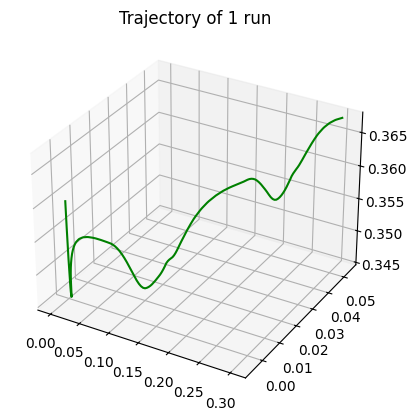

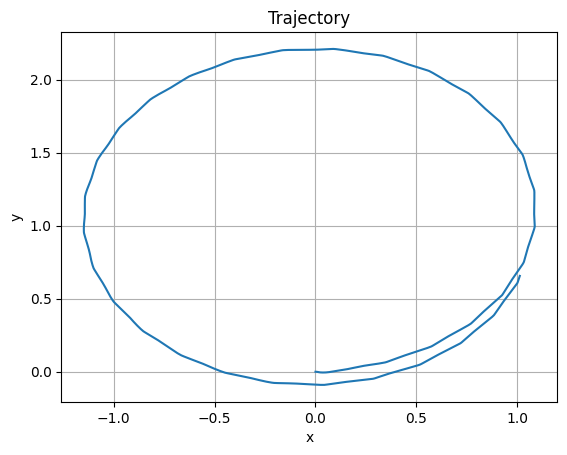

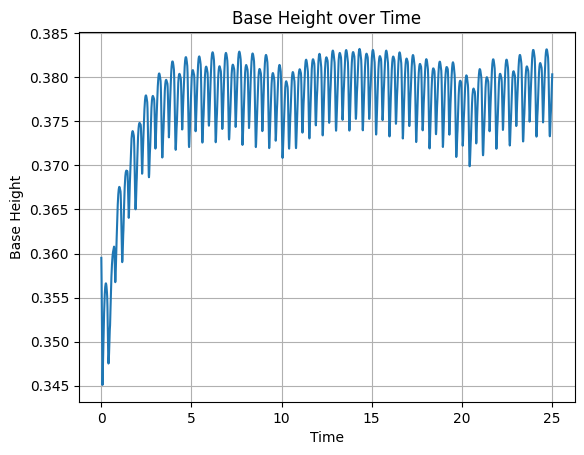

In [4]:
import numpy as np
import matplotlib.pyplot as plt

sim_num = 0
dataset_num = 2
data = load_custom_dataset(dataset_path=Path.cwd().parent / f"custom_datasets/quad_dataset_run{dataset_num}.npz", sim_num=sim_num)

fig = plt.figure()
ax = plt.axes(projection='3d')
base_pos = data["base_pos"]

x = base_pos[:, 0][:200]
y = base_pos[:, 1][:200]
z = base_pos[:, 2][:200]

ax.plot3D(x, y, z, 'green')
ax.set_title(f'Trajectory of {sim_num+1} run')
plt.show()

base_plot(data["time"], data["base_pos"])

In [ ]:
print(20*"=", f"Simulation no. {sim_num+1}", 20*"=")

# case 1: everything is given
# result = run_state_estimation(dt=data["dt"][0],
#                               base_pos=data["base_pos"],
#                               base_orient=data["base_orient"],
#                               base_acc=data["base_acc"],
#                               base_ang_vel=data["base_ang_vel"],
#                               joint_pos=data["joint_pos"],
#                               joint_vel=data["joint_vel"],
#                               contact_states=data["contact_states"],
#                               contact_forces=data["contact_forces"],
#                               contact_pos=data["contact_pos"],
#                               Q=0.002, 
#                               R=0.01,)

# base acc has to be estimated
# case 2: from measured contact force and state
# result = run_state_estimation(dt=data["dt"][0],
#                               base_pos=data["base_pos"],
#                               base_orient=data["base_orient"],
#                               base_ang_vel=data["base_ang_vel"],
#                               joint_pos=data["joint_pos"],
#                               joint_vel=data["joint_vel"],
#                               contact_states=data["contact_states"],
#                               contact_forces=data["contact_forces"],
#                               contact_pos=data["contact_pos"],
#                               Q=0.002, 
#                               R=0.01,)

# # case 3: from estimated contact force from jacobian and joint torque
# result = run_state_estimation(dt=data["dt"][0],
#                               base_pos=data["base_pos"],
#                               base_orient=data["base_orient"],
#                               base_ang_vel=data["base_ang_vel"],
#                               joint_pos=data["joint_pos"],
#                               joint_vel=data["joint_vel"],
#                               joint_torque=data["joint_torque"],
#                               contact_states=data["contact_states"],
#                               contact_pos=data["contact_pos"],
#                               Q=0.002, 
#                               R=0.01,)

# # case 4: from measured contact force, joint torque and estimated contact state based of force
result = run_state_estimation(dt=data["dt"][0],
                              base_pos=data["base_pos"],
                              base_orient=data["base_orient"],
                              base_ang_vel=data["base_ang_vel"],
                              joint_pos=data["joint_pos"],
                              joint_vel=data["joint_vel"],
                              joint_torque=data["joint_torque"],
                              contact_forces=data["contact_forces"],
                              contact_pos=data["contact_pos"],
                              Q=0.002, 
                              R=0.01,)

# case 5 (Leg-KILO): using measured force (single value) to estimate state and joint torque to estimate real contact force

## Estimation for one Simulation

Investigating the following methods:
- Leg Odometry alone
- Leg Odom + Kalman Filter without considering dynamics (given base acc and setting it to 0)
- Leg Odom + Kalman Filter with dynamics (estimating base acc with given contact force)
- Leg Odom + Kalman Filter with dynamics and estimation of contact force

In [2]:
sim_num = 0
dataset_num = 2
data = load_custom_dataset(dataset_path=Path.cwd().parent / f"custom_datasets/quad_dataset_run{dataset_num}.npz", sim_num=sim_num)

Data loaded from /home/jad/Uni/semester-2/RL-IP_Part-1/mpx/custom_datasets/quad_dataset_run2.npz.


### Leg Odom alone

In [5]:
result_gt_acc = run_state_estimation(dt=data["dt"][0],
                            base_pos=data["base_pos"],
                            base_orient=data["base_orient"],
                            base_acc=data["base_acc"],
                            base_ang_vel=data["base_ang_vel"],
                            joint_pos=data["joint_pos"],
                            joint_vel=data["joint_vel"],
                            contact_states=data["contact_states"],
                            contact_forces=data["contact_forces"],
                            contact_pos=data["contact_pos"],
                            Q=0.0001,
                            R=[1, 1, 1],
                            result_dir=f"results/simulation/sim_{sim_num+1}",
                            file_name="leg_odom_alone")

dim = ["x", "y", "z"]
mse_result_gt_acc = [0, 0, 0, 0, 0, 0]
mse_result2_gt_acc = [0, 0, 0, 0, 0, 0]
for i in range(len(dim)):    
    mse_result_gt_acc[i] = mean_squared_error(data["base_vel"][:, i], result_gt_acc["leg_odom"][:, i])
    mse_result_gt_acc[i+3] = mean_squared_error(data["base_pos"][:, i], result_gt_acc["leg_odom_pos"][:, i])

    mse_result2_gt_acc[i] = mean_squared_error(data["base_vel"][:, i], result_gt_acc["vel_update"][:, i])
    mse_result2_gt_acc[i+3] = mean_squared_error(data["base_pos"][:, i], result_gt_acc["pos_update"][:, i])


for i in range(len(mse_result_gt_acc)):
    if i < 3:
        val = "vel"
    else:
        val = "pos"
    print(f"MSE Error of Leg Odometry - {val} {dim[i%3]}: {mse_result_gt_acc[i]}")
    print(f"MSE Error of KF Estimation - {val} {dim[i%3]}: {mse_result2_gt_acc[i]}\n")

/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Estimating state: 100%|██████████| 5000/5000 [00:03<00:00, 1617.99it/s]

Result saved in /home/undefined/Uni/semester-2/RL-IP_Part-1/mpx/results/simulation/sim_1/leg_odom_alone
MSE Error of Leg Odometry - vel x: 0.006168911980821577
MSE Error of KF Estimation - vel x: 0.00020190007324862142

MSE Error of Leg Odometry - vel y: 0.004347858600565534
MSE Error of KF Estimation - vel y: 0.00015829153972960985

MSE Error of Leg Odometry - vel z: 0.02621600442688677
MSE Error of KF Estimation - vel z: 0.0014632925959338584

MSE Error of Leg Odometry - pos x: 0.0022660642813417766
MSE Error of KF Estimation - pos x: 0.0022580759329166276

MSE Error of Leg Odometry - pos y: 0.006822927253975244
MSE Error of KF Estimation - pos y: 0.006944352788605454

MSE Error of Leg Odometry - pos z: 0.330520535981807
MSE Error of KF Estimation - pos z: 0.2884813508362317



In [18]:
import matplotlib.pyplot as plt

def compare_estimation_plot(time, 
                            gt_values, 
                            gt_label, 
                            pred_values, 
                            pred_labels, 
                            ylabel, 
                            title, 
                            output_folder=None, 
                            file_name=None, 
                            colors=None, 
                            combined_plot=True, 
                            time_window=None, 
                            font_size=None,
                            show_legend=True,
                            seperate_legend=False):
    """

    Args:
        time (np.array): Time
        gt_values (np.array): Array of ground truth values
        pred_values (list): List of arrays with predicted values
        pred_labels (list): List with corresponding labels
        ylabel (str): Y-label
        title (str): Title
        combined_plot (bool, optional): If True, plot values of each prediction in one plot, else seperated. Defaults to True.
    """

    if font_size: plt.rcParams.update({'font.size': font_size})

    if len(pred_values) != len(pred_labels):
        print(f"prediction arrays and labels have different len: {len(pred_values)} and {len(pred_labels)}")
        return

    pred_shapes = [arr.shape for arr in pred_values]
    gt_shape = gt_values.shape
    shape_match = all(shape == gt_shape for shape in pred_shapes)
    if not shape_match:
        print(f"gt_values and pred_values have different number of dimensions: {gt_shape} and {pred_shapes}")
        return
    
    if colors is None: colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    num_plots = 1 if combined_plot else len(pred_values)
    num_dim = gt_shape[1]
    if time_window is not None:
        if not isinstance(time_window, list): 
            print("time_window must be type list")
            return
        if len(time_window) != 2:
            print("time_window must have 2 values")
            return
    fig_size = (16,8) if combined_plot else (20,15)
    _, axes = plt.subplots(num_plots, 1, figsize=fig_size, sharex=combined_plot)

    for j in range(num_plots):
        for i in range(num_dim):
            if combined_plot:
                axes.plot(time, gt_values[:, i], "--", label=gt_label, color=colors[j])
            else:
                axes[j].plot(time, gt_values[:, i], "--", label=gt_label, color=colors[j])

    if combined_plot:
        for k, prediction in enumerate(pred_values):
            for i in range(num_dim):
                axes.plot(time, prediction[:, i], linestyle="-", label=f"{pred_labels[k]}", alpha=0.5, color=colors[k+1])
    else:
        for j in range(num_plots):
            prediction = pred_values[j]
            for i in range(num_dim):
                axes[j].plot(time, prediction[:, i], linestyle="-", label=f"{pred_labels[j]}", alpha=0.5, color=colors[j+1])

    if combined_plot:
        axes.set_xlabel("Time [s]")
        axes.set_ylabel(ylabel)
        axes.set_title(title)
        axes.grid(True)
        if time_window is not None: axes.set_xlim(time_window)
        if show_legend: axes.legend()
    else:
        for j in range(num_plots):
            axes[j].set_xlabel("Time [s]")
            axes[j].set_ylabel(ylabel)
            axes[j].set_title(title)
            axes[j].grid(True)
            if time_window is not None: axes[j].set_xlim(time_window)
            if show_legend: axes[j].legend()
    
    if output_folder is not None: 
        os.makedirs(output_folder, exist_ok=True)
        plt.savefig(output_folder+"/"+file_name+".png", bbox_inches='tight')
        plt.savefig(output_folder+"/"+file_name+".pdf", bbox_inches='tight')

    if seperate_legend: 
        legend = axes.legend()
        fig_leg = plt.figure(figsize=(2,2))
        fig_leg.legend(*axes.get_legend_handles_labels(), loc="center")
        fig_leg.savefig("legend.png", bbox_inches="tight")
        plt.close(fig_leg)

        if not show_legend: legend.remove()
    plt.tight_layout()
    plt.show()


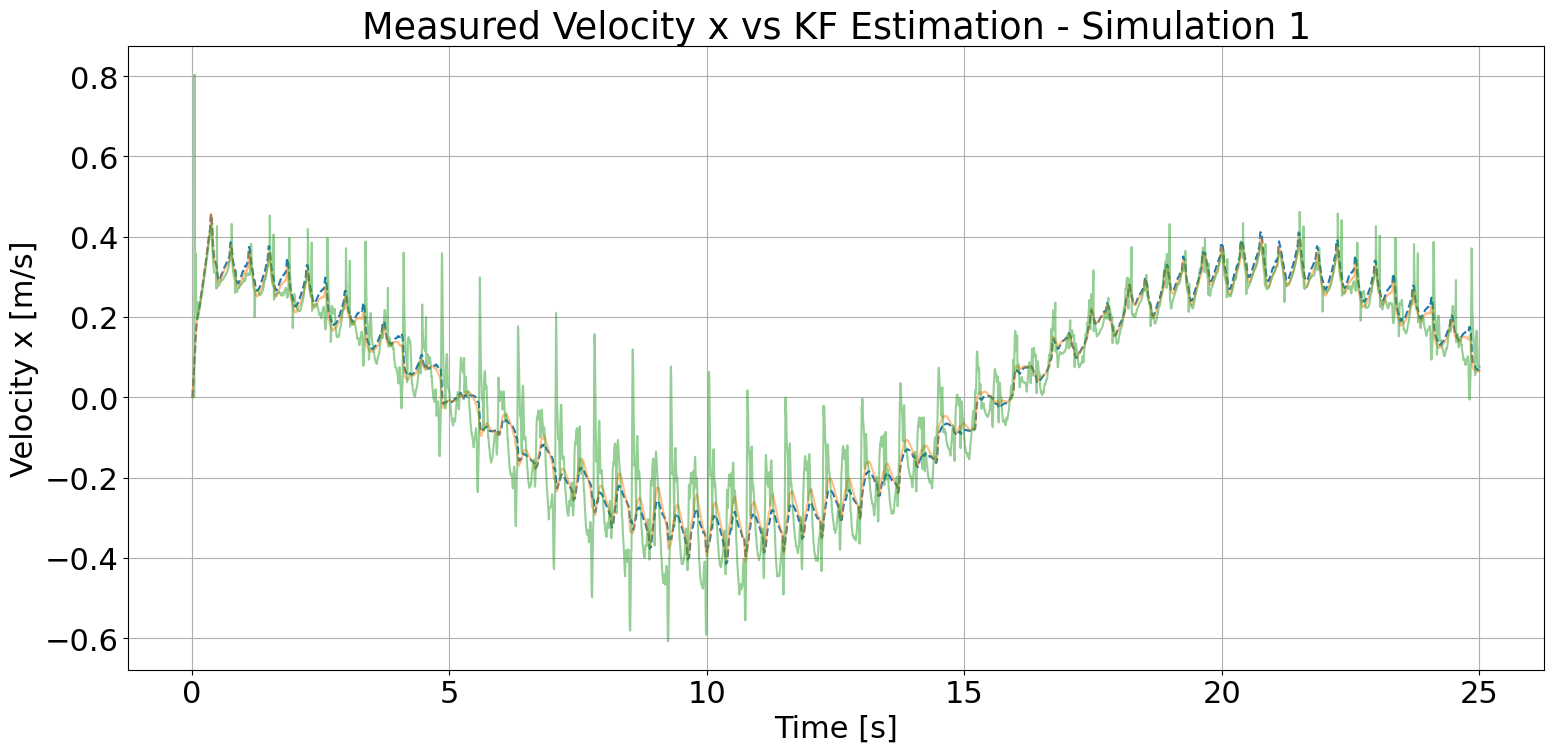

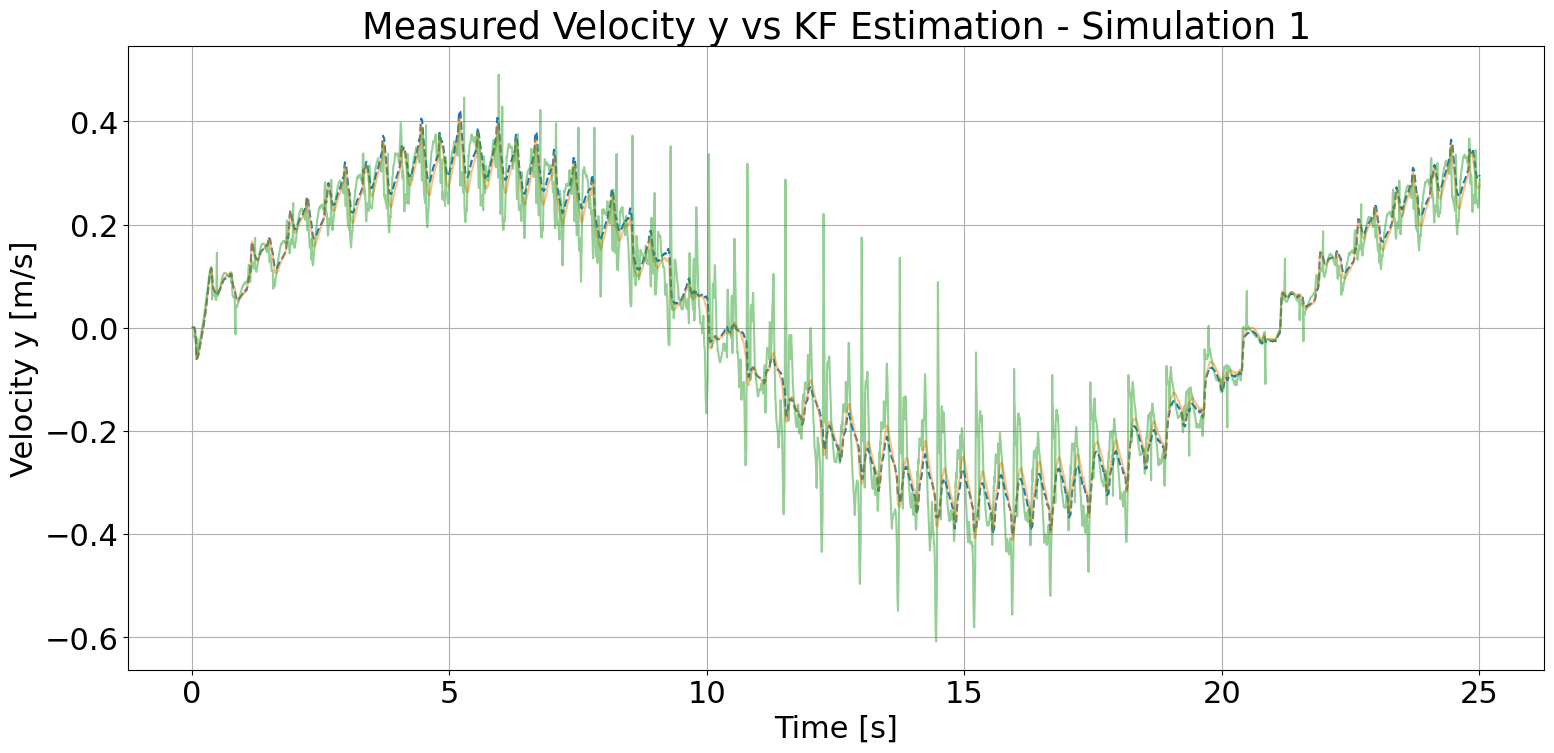

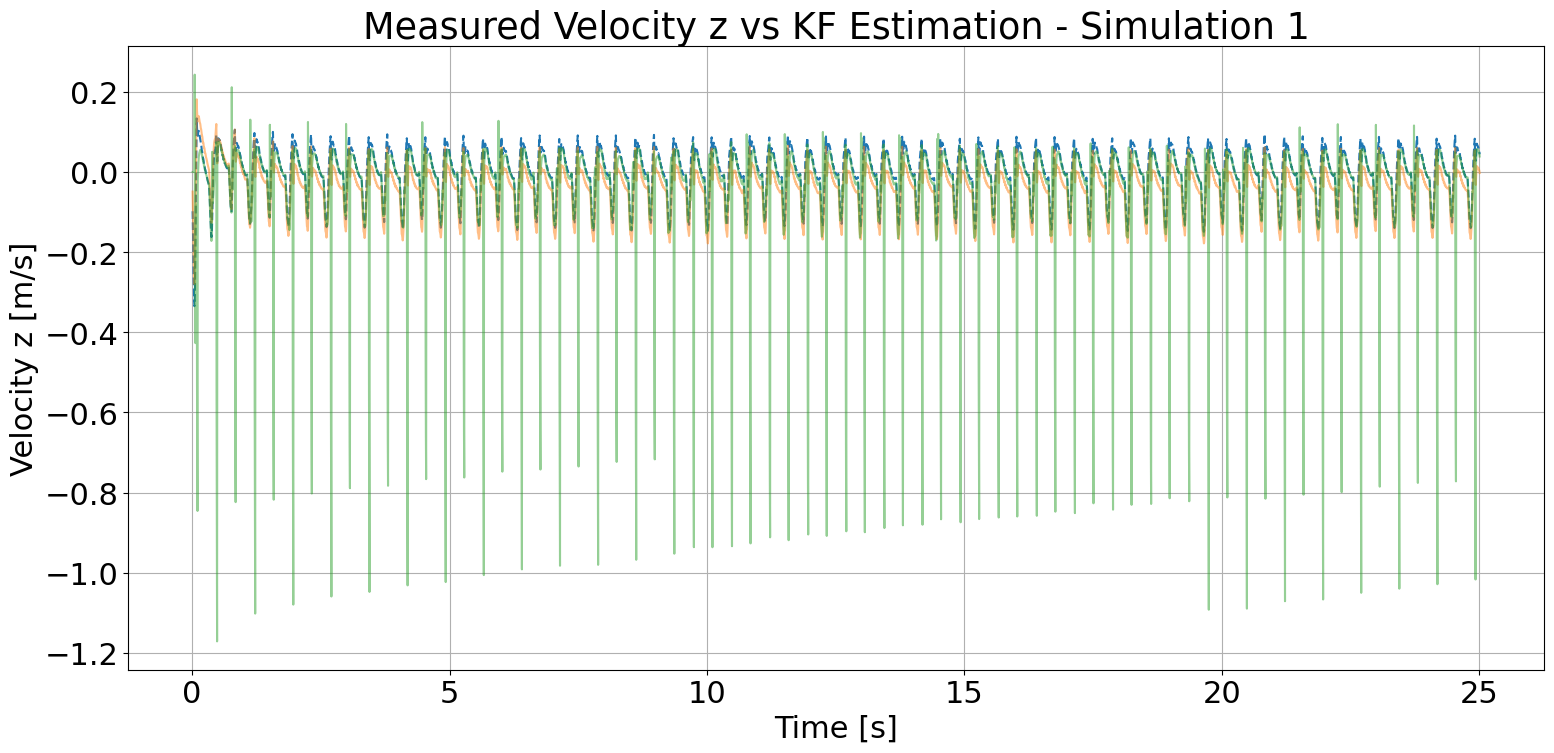

In [16]:
colors = ['#1f77b4', # gt
        '#ff7f0e', # gt_acc
        '#2ca02c', # leg odom
        # '#d62728', # leg odom + kf, acc=0
        # '#9467bd', # leg odom + kf, dynamics
        # '#8c564b'  # leg odom + kf, dynamics with est cf
        ]

data_dir = Path.cwd().parent / f"results/simulation/sim_{sim_num+1}"
result_gt_acc = np.load(f"{data_dir}/leg_odom_alone.npz")

for i in range(len(dim)):
    gt_values = data["base_vel"][:, i:i+1]

    pred_values = [result_gt_acc["vel_update"][:, i:i+1],
                   result_gt_acc["leg_odom"][:, i:i+1]]

    pred_labels = ["Ground truth base acc",
                   "Leg Odom"]

    compare_estimation_plot(time=data["time"],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Velocity {dim[i]} [m/s]",
                            title=f"Measured Velocity {dim[i]} vs KF Estimation - Simulation {sim_num+1}",
                            colors=colors,
                        #     output_folder=f"/home/undefined/Uni/semester-2/RL-IP_Part-1/report/sim{sim_num+1}",
                        #     file_name=f"Leg_odom_with_gt_{dim[i]}",
                            font_size=22,
                            show_legend=False)

### Leg Odom + KF without considering dynamics (base acc = 0)

In [19]:
result_acc_0 = run_state_estimation(dt=data["dt"][0],
                            base_pos=data["base_pos"],
                            base_orient=data["base_orient"],
                            base_acc=np.zeros(data["base_acc"].shape),
                            base_ang_vel=data["base_ang_vel"],
                            joint_pos=data["joint_pos"],
                            joint_vel=data["joint_vel"],
                            contact_states=data["contact_states"],
                            contact_forces=data["contact_forces"],
                            contact_pos=data["contact_pos"],
                            Q=0.0001,
                            R=[1, 1, 1],
                            result_dir=f"results/simulation/sim_{sim_num+1}",
                            file_name="kf_est-no_dynamics")

dim = ["x", "y", "z"]
mse_result_acc_0 = [0, 0, 0, 0, 0, 0]
for i in range(len(dim)):    
    mse_result_acc_0[i] = mean_squared_error(data["base_vel"][:, i], result_acc_0["vel_update"][:, i])
    mse_result_acc_0[i+3] = mean_squared_error(data["base_pos"][:, i], result_acc_0["pos_update"][:, i])


for i in range(len(mse_result_acc_0)):
    if i < 3:
        val = "vel"
    else:
        val = "pos"
    print(f"MSE Error of KF Estimation - {val} {dim[i%3]}: {mse_result_acc_0[i]}\n")

/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Estimating state: 100%|██████████| 5000/5000 [00:03<00:00, 1617.05it/s]

Result saved in /home/undefined/Uni/semester-2/RL-IP_Part-1/mpx/results/simulation/sim_1/kf_est-no_dynamics
MSE Error of KF Estimation - vel x: 0.003675760421367738

MSE Error of KF Estimation - vel y: 0.0021317021806396166

MSE Error of KF Estimation - vel z: 0.00553249172640203

MSE Error of KF Estimation - pos x: 0.019436738356043953

MSE Error of KF Estimation - pos y: 0.010949310894872246

MSE Error of KF Estimation - pos z: 0.30834849068686476



### Leg Odom + KF with dynamics (estimating base acc with given contact force)

In [20]:
result_est_acc_gt_c_force = run_state_estimation(dt=data["dt"][0],
                            base_pos=data["base_pos"],
                            base_orient=data["base_orient"],
                            base_ang_vel=data["base_ang_vel"],
                            joint_pos=data["joint_pos"],
                            joint_vel=data["joint_vel"],
                            contact_states=data["contact_states"],
                            contact_forces=data["contact_forces"],
                            contact_pos=data["contact_pos"],
                            Q=0.0001,
                            R=[1, 1, 1],
                            result_dir=f"results/simulation/sim_{sim_num+1}",
                            file_name="kf_est-dynamics-gt_c_force")
dim = ["x", "y", "z"]
mse_result_est_acc_gt_c_force= [0, 0, 0, 0, 0, 0]
for i in range(len(dim)):    
    mse_result_est_acc_gt_c_force[i] = mean_squared_error(data["base_vel"][:, i], result_est_acc_gt_c_force["vel_update"][:, i])
    mse_result_est_acc_gt_c_force[i+3] = mean_squared_error(data["base_pos"][:, i], result_est_acc_gt_c_force["pos_update"][:, i])


for i in range(len(mse_result_est_acc_gt_c_force)):
    if i < 3:
        val = "vel"
    else:
        val = "pos"
    print(f"MSE Error of KF Estimation - {val} {dim[i%3]}: {mse_result_est_acc_gt_c_force[i]}\n")

/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Estimating base_acc.


Estimating state: 100%|██████████| 5000/5000 [00:03<00:00, 1643.90it/s]


Result saved in /home/undefined/Uni/semester-2/RL-IP_Part-1/mpx/results/simulation/sim_1/kf_est-dynamics-gt_c_force
MSE Error of KF Estimation - vel x: 0.00013418039533627277

MSE Error of KF Estimation - vel y: 9.383006349947722e-05

MSE Error of KF Estimation - vel z: 0.0021804468193367295

MSE Error of KF Estimation - pos x: 0.0023772807624456867

MSE Error of KF Estimation - pos y: 0.007681582709390924

MSE Error of KF Estimation - pos z: 0.2596630925379375



### Leg Odom + KF with dynamics (estimating base acc with estimated contact force)

In [3]:
result_est_acc_est_c_force = run_state_estimation(dt=data["dt"][0],
                                      base_pos=data["base_pos"],
                                      base_orient=data["base_orient"],
                                      base_ang_vel=data["base_ang_vel"],
                                      joint_pos=data["joint_pos"],
                                      joint_vel=data["joint_vel"],
                                      joint_torque=data["joint_torque"],
                                      contact_states=data["contact_states"],
                                      contact_pos=data["contact_pos"],
                                      Q=0.0001,
                                      R=[1, 1, 1],
                                      result_dir=f"results/simulation/sim_{sim_num+1}",
                                      file_name="kf_est-dynamics-base_acc_est-c_force_est")

dim = ["x", "y", "z"]
mse_result_est_acc_est_c_force = [0, 0, 0, 0, 0, 0]
for i in range(len(dim)):    
    mse_result_est_acc_est_c_force[i] = mean_squared_error(data["base_vel"][:, i], result_est_acc_est_c_force["vel_update"][:, i])
    mse_result_est_acc_est_c_force[i+3] = mean_squared_error(data["base_pos"][:, i], result_est_acc_est_c_force["pos_update"][:, i])


for i in range(len(mse_result_est_acc_est_c_force)):
    if i < 3:
        val = "vel"
    else:
        val = "pos"
    print(f"MSE Error of KF Estimation - {val} {dim[i%3]}: {mse_result_est_acc_est_c_force[i]}\n")

Estimating base_acc.
Estimating contact_force from contact_state and joint_torque


/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Estimating state: 100%|██████████| 5000/5000 [00:11<00:00, 449.16it/s]

Result saved in /home/jad/Uni/semester-2/RL-IP_Part-1/mpx/results/simulation/sim_1/kf_est-dynamics-base_acc_est-c_force_est
MSE Error of KF Estimation - vel x: 0.053061806781930315

MSE Error of KF Estimation - vel y: 0.05235216564082375

MSE Error of KF Estimation - vel z: 23.345680306050408

MSE Error of KF Estimation - pos x: 0.09402463326025556

MSE Error of KF Estimation - pos y: 0.03444590802202158

MSE Error of KF Estimation - pos z: 3.221305411937877



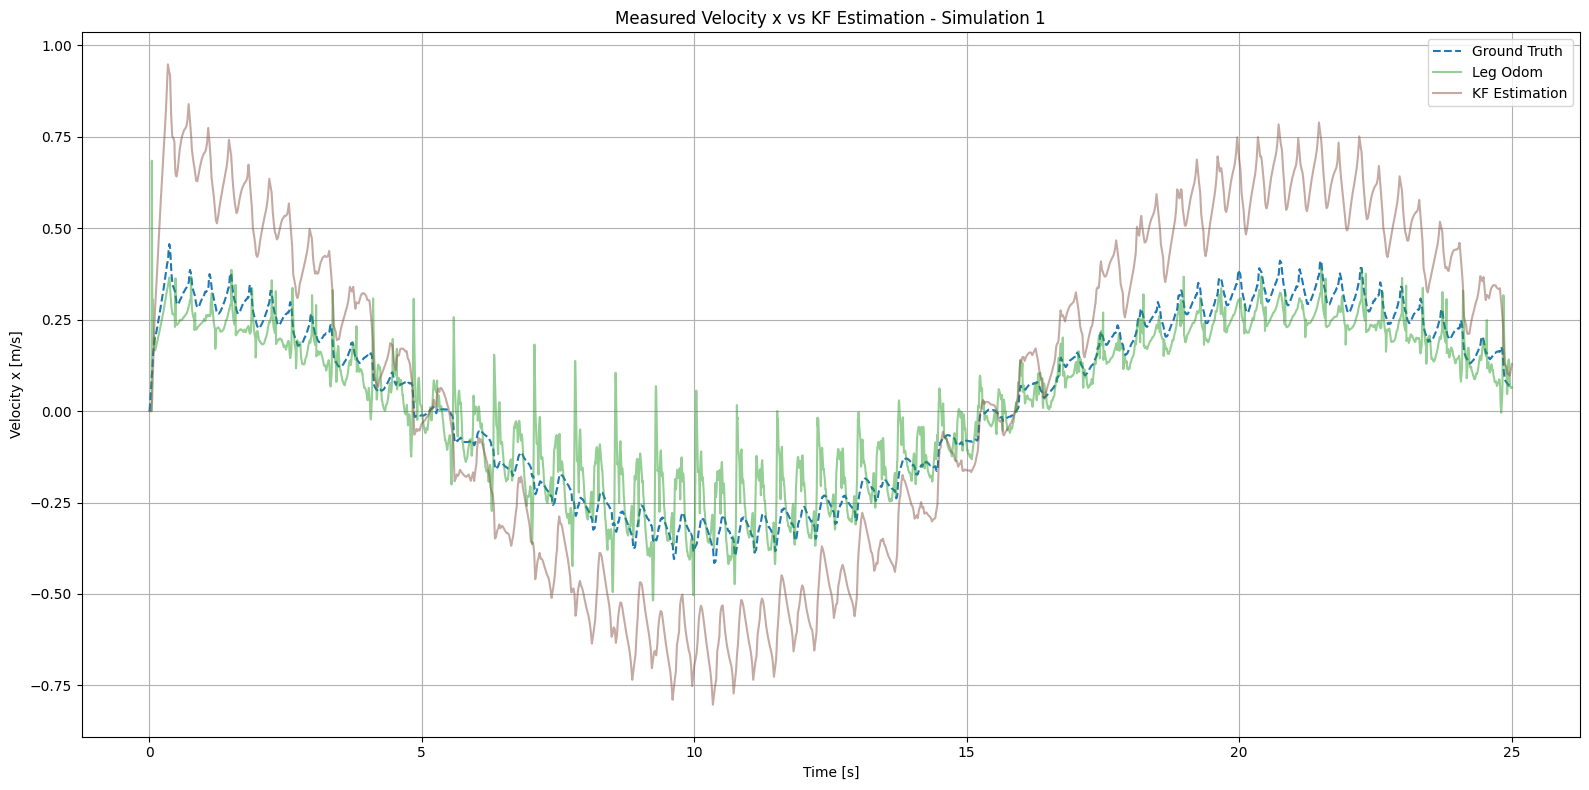

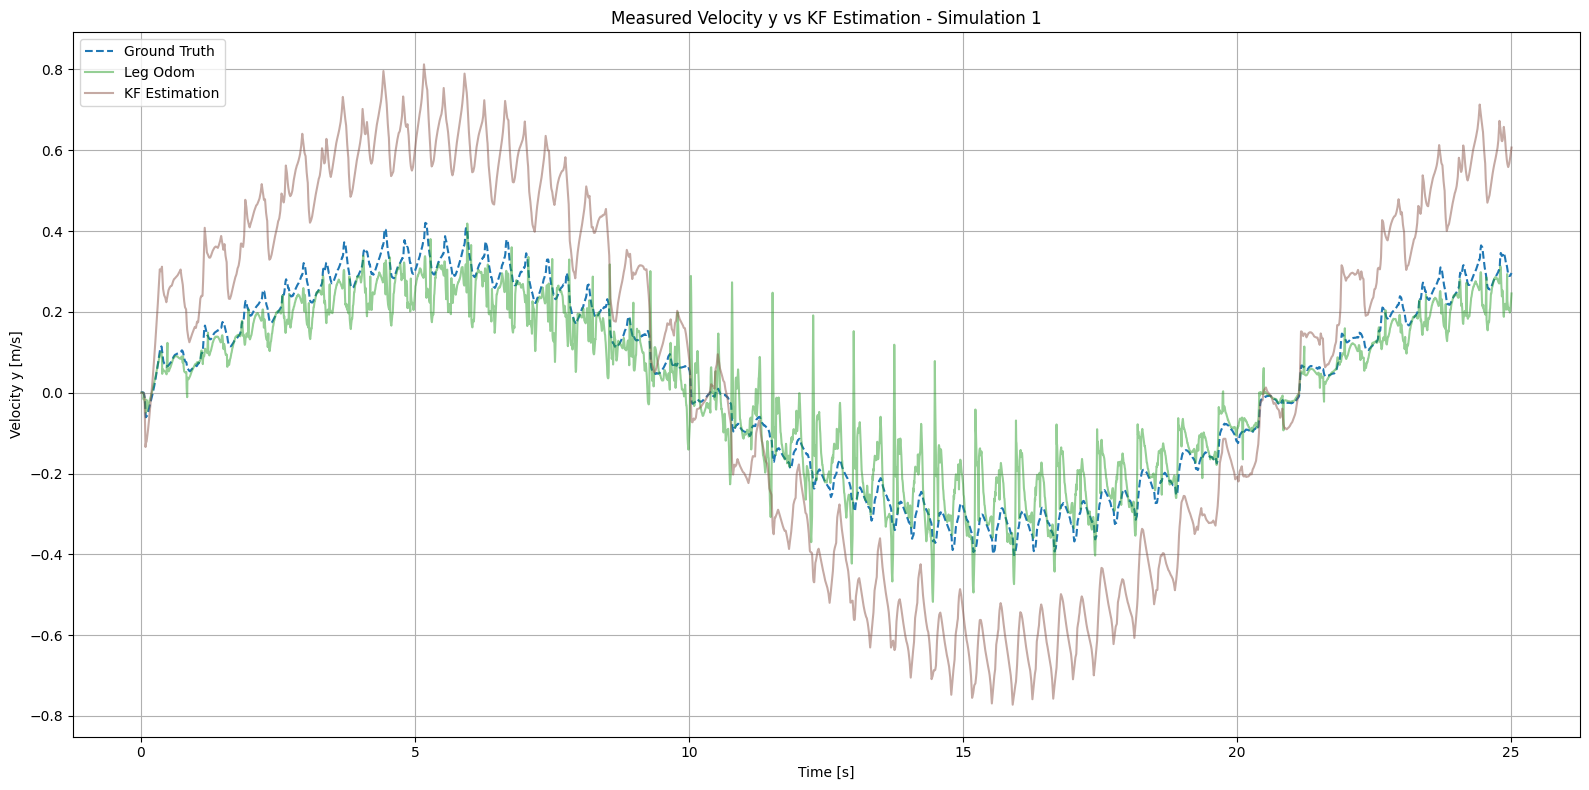

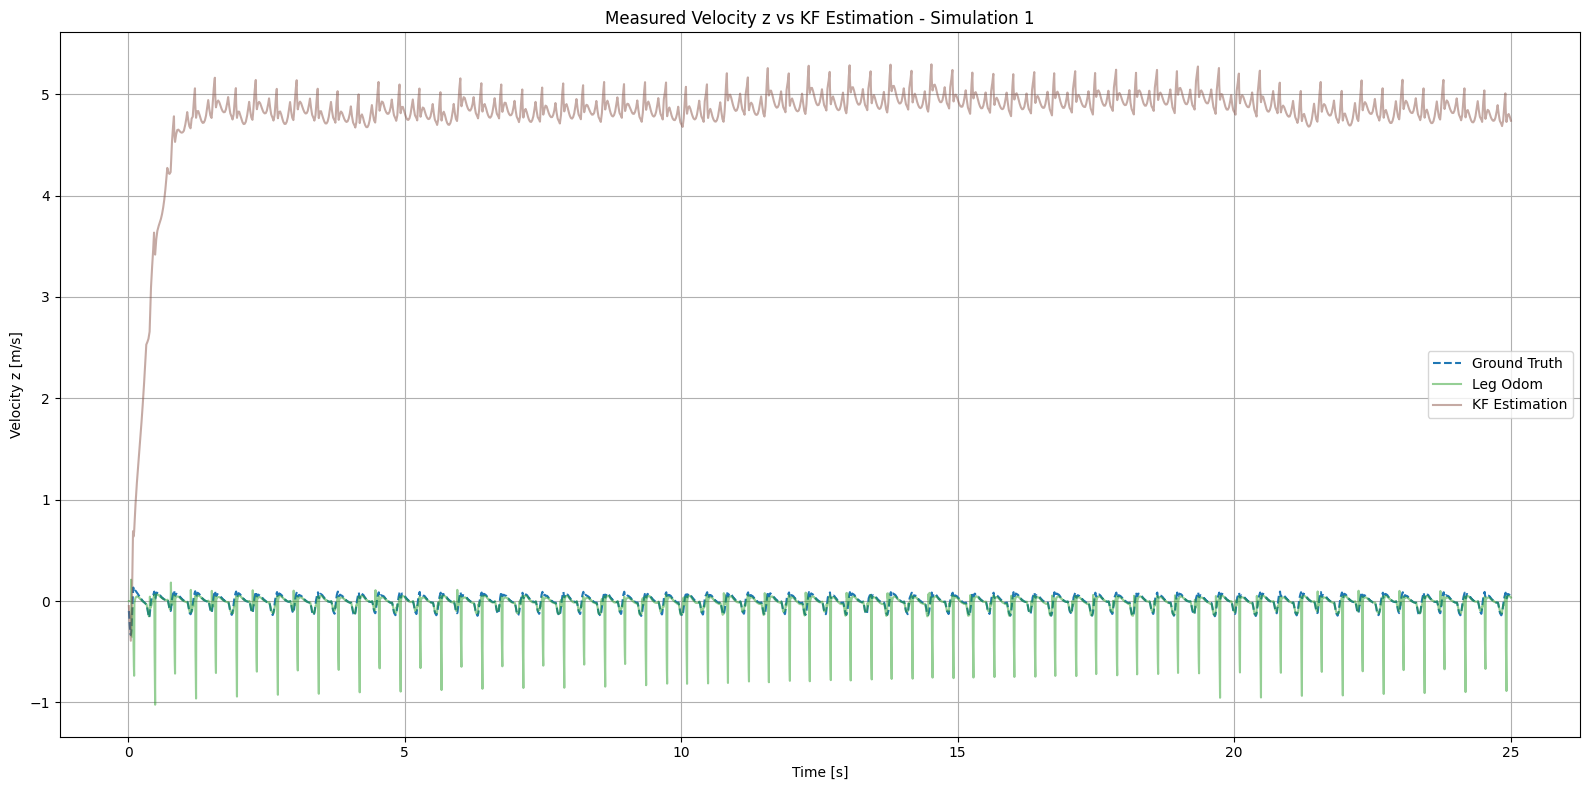

In [5]:
colors = ['#1f77b4', # gt
        # '#ff7f0e', # gt_acc
        '#2ca02c', # leg odom
        # '#d62728', # leg odom + kf, acc=0
        # '#9467bd', # leg odom + kf, dynamics
        '#8c564b'  # leg odom + kf, dynamics with est cf
        ]

data_dir = Path.cwd().parent / f"results/simulation/sim_{sim_num+1}"
result_gt_acc = np.load(f"{data_dir}/leg_odom_alone.npz")

for i in range(len(dim)):
    gt_values = data["base_vel"][:, i:i+1]

    pred_values = [result_est_acc_est_c_force["leg_odom"][:, i:i+1],
                   result_est_acc_est_c_force["vel_update"][:, i:i+1]]

    pred_labels = ["Leg Odom",
                   "KF Estimation",]

    compare_estimation_plot(time=data["time"],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Velocity {dim[i]} [m/s]",
                            title=f"Measured Velocity {dim[i]} vs KF Estimation - Simulation {sim_num+1}",
                            colors=colors)

### Combining plots

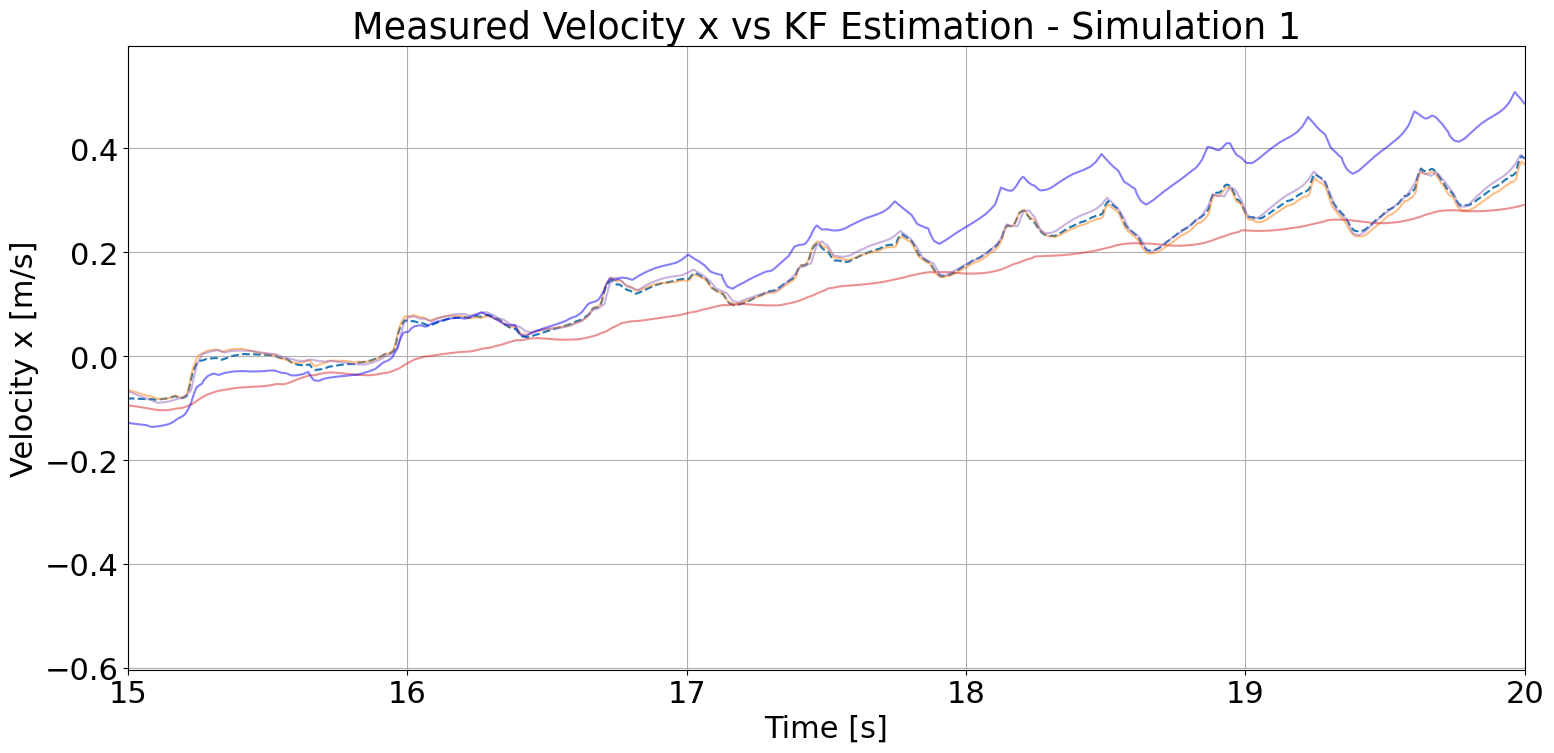

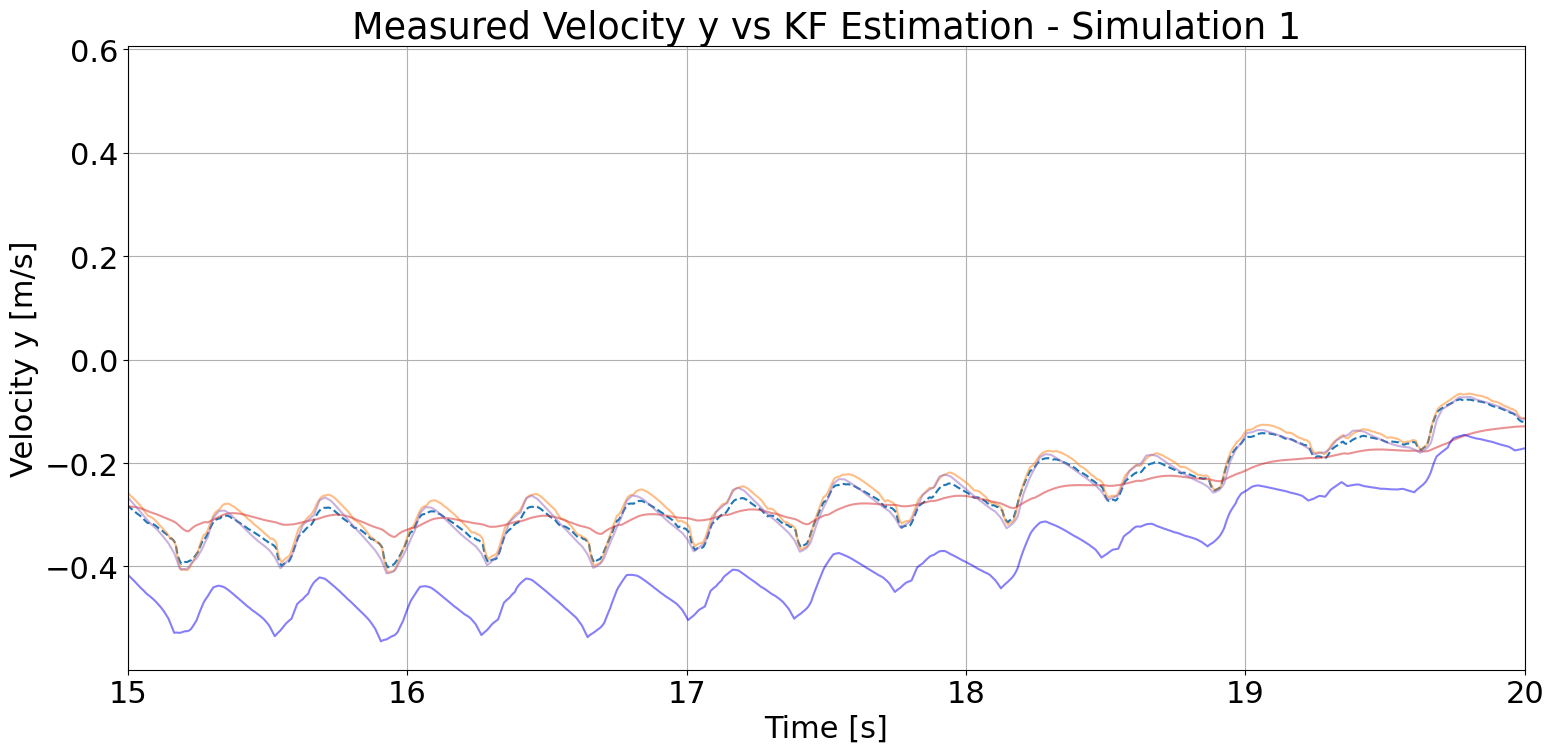

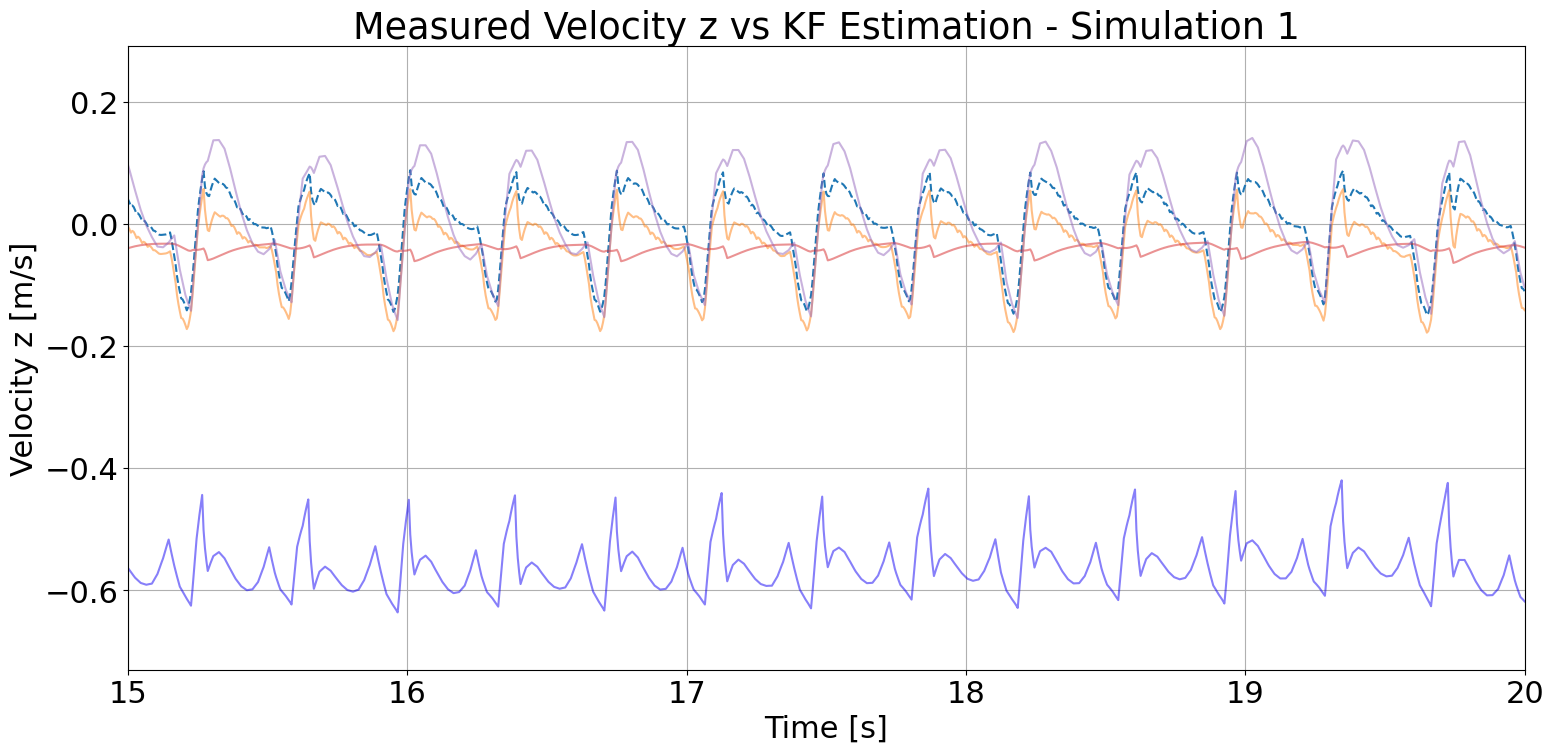

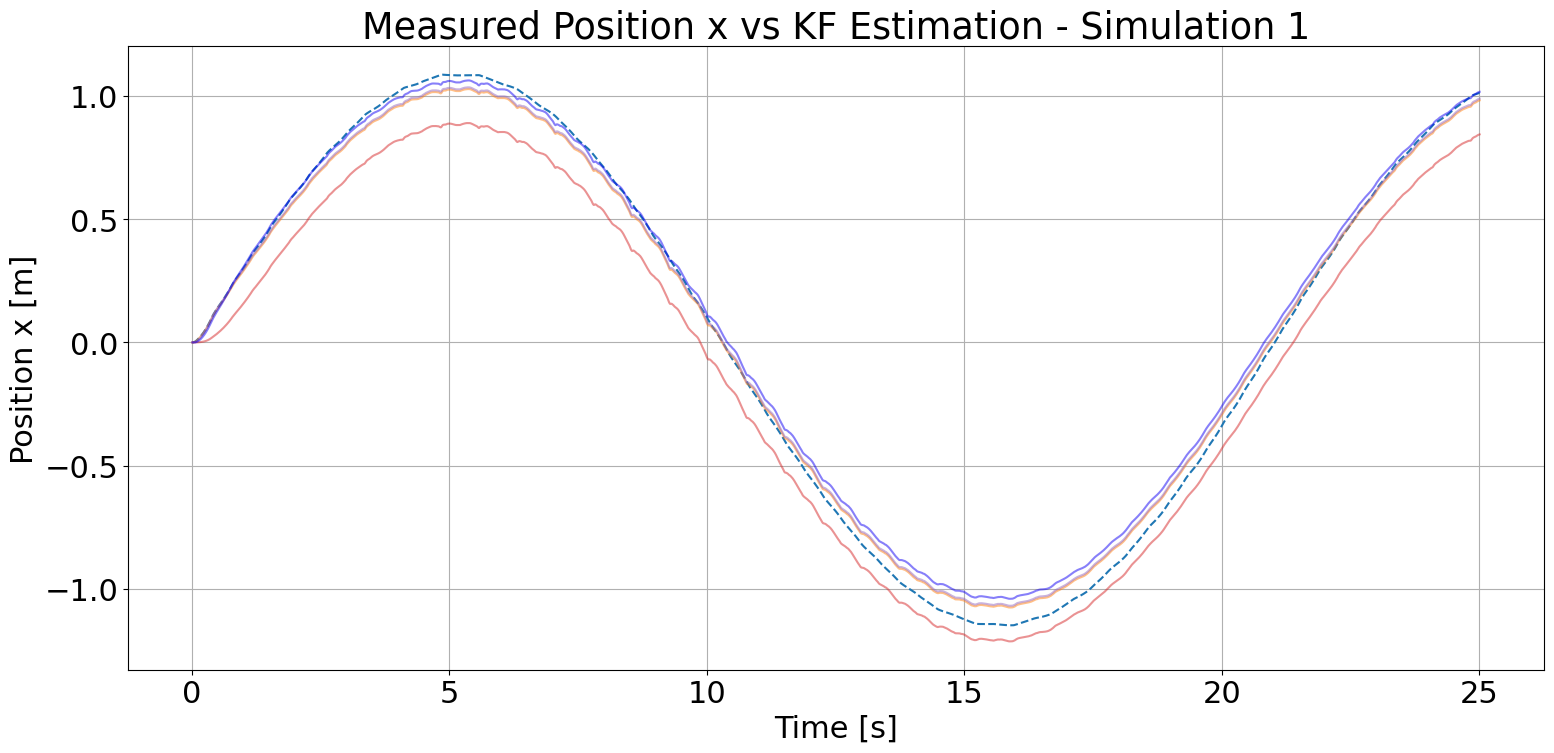

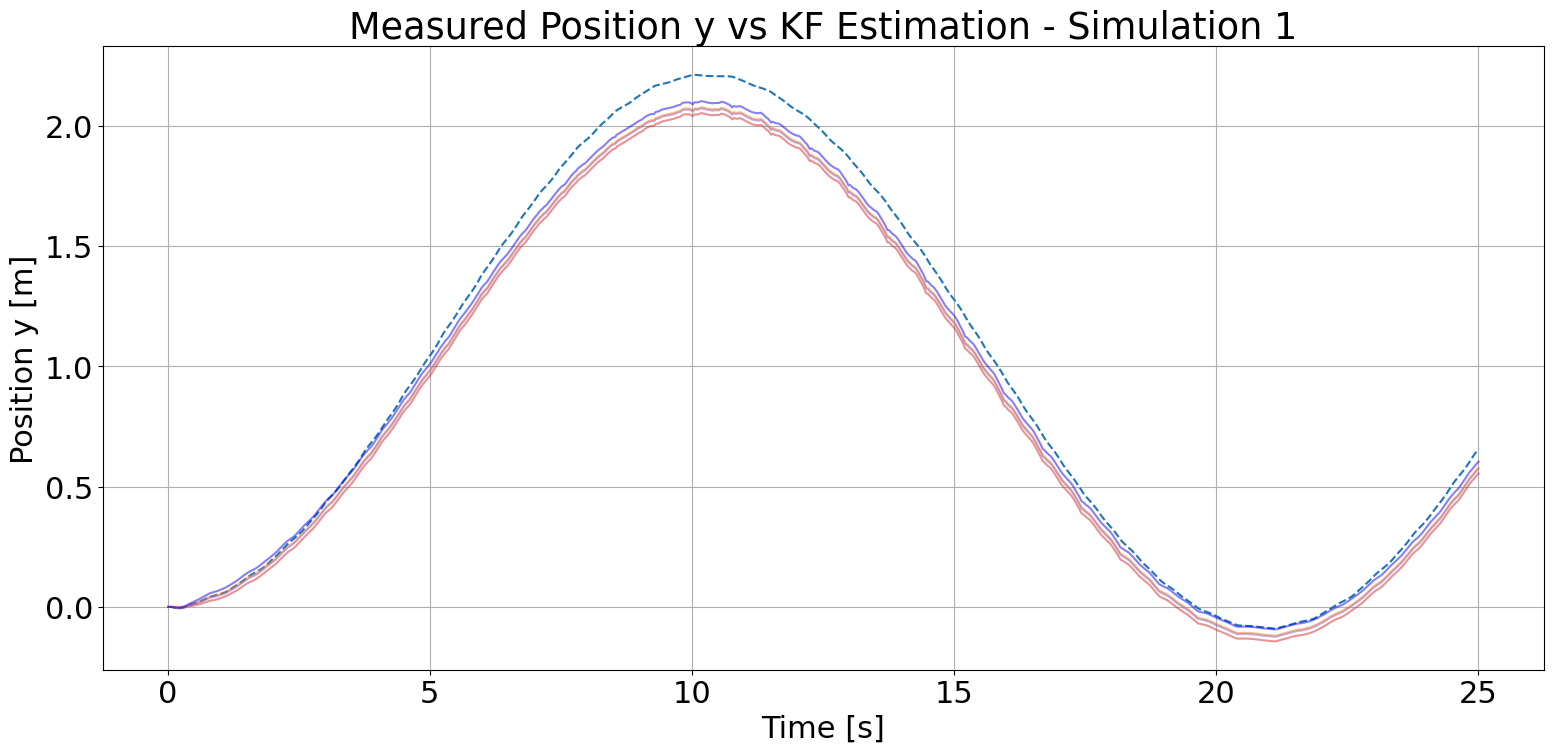

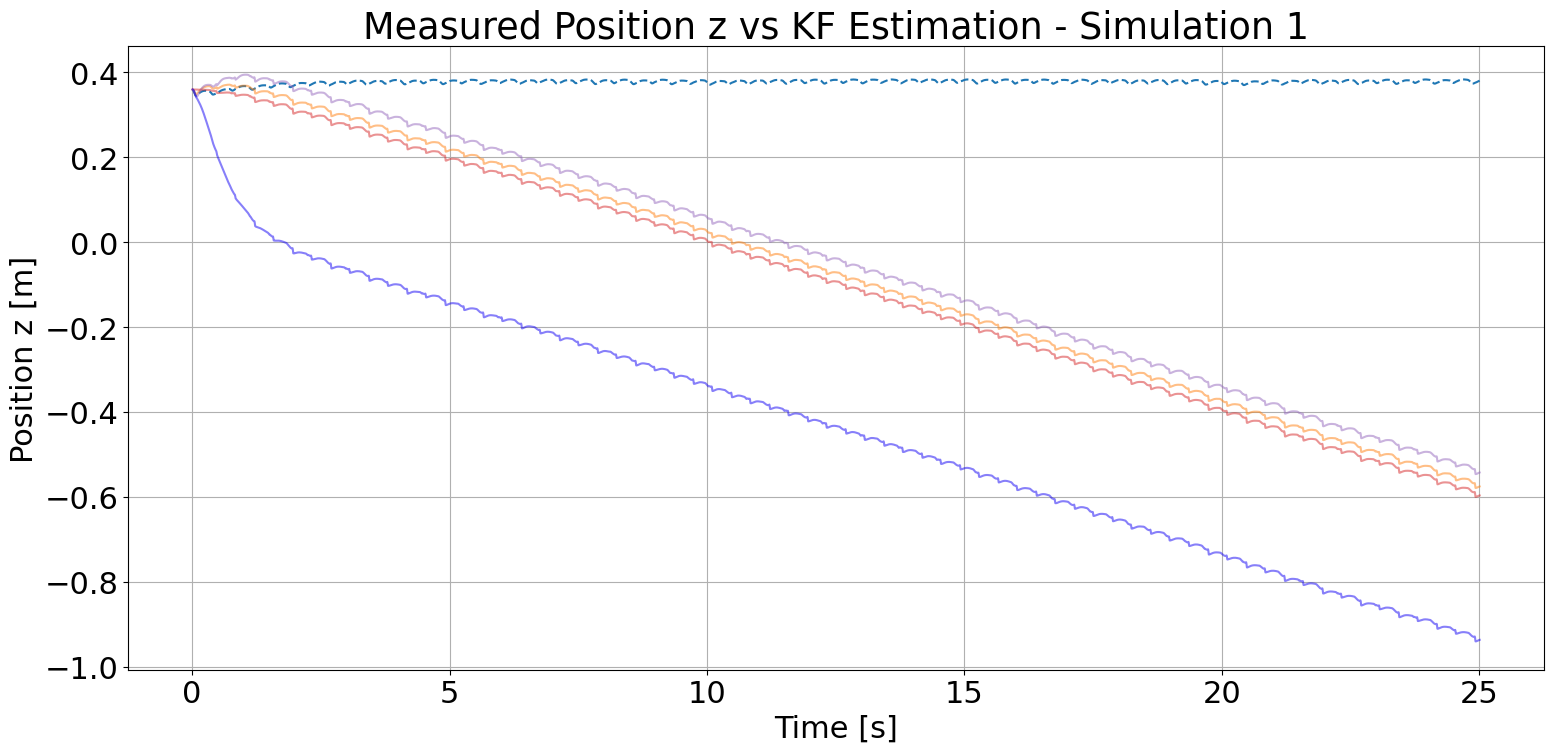

In [22]:
colors = ['#1f77b4', # gt
        '#ff7f0e', # gt_acc
        # '#2ca02c', # leg odom
        '#d62728', # leg odom + kf, acc=0
        '#9467bd', # leg odom + kf, dynamics
        "#1000f5"  # leg odom + kf, dynamics with est cf
        ]

# data_dir = Path.cwd().parent / f"results/simulation/sim_{sim_num+1}"
# result_gt_acc = np.load(f"{data_dir}/leg_odom_alone.npz")
# result_acc_0 = np.load(f"{data_dir}/kf_est-no_dynamics.npz")
# result_est_acc_gt_c_force = np.load(f"{data_dir}/kf_est-dynamics-gt_c_force.npz")
# result_est_acc_est_c_force = np.load(f"{data_dir}/kf_est-dynamics-base_acc_est-c_force_est.npz")

pred_labels = ["Ground truth base acc",
                "Leg Odom + KF with no dynamics model",
                "Leg Odom + KF with dynamics model (gt contact force)",
                "Leg Odom + KF with dynamics model (est. contact force)"
                ]

for i, dim in enumerate(["x", "y", "z"]):
    gt_values = data["base_vel"][:, i:i+1]

    pred_values = [result_gt_acc["vel_update"][:, i:i+1],
                    result_acc_0["vel_update"][:, i:i+1],
                    result_est_acc_gt_c_force["vel_update"][:, i:i+1],
                    result_est_acc_est_c_force["vel_update"][:, i:i+1]
                    ]

    compare_estimation_plot(time=data["time"],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Velocity {dim} [m/s]",
                            title=f"Measured Velocity {dim} vs KF Estimation - Simulation {sim_num+1}",
                            colors=colors,
                            # output_folder=f"/home/undefined/Uni/semester-2/RL-IP_Part-1/report/sim{sim_num+1}",
                            # file_name=f"Dynamics-Velocity_{dim}",
                            time_window=[15,20],
                            font_size=22,
                            show_legend=False,
                            seperate_legend=True
                            )

for i, dim in enumerate(["x", "y", "z"]):
    gt_values = data["base_pos"][:, i:i+1]

    pred_values = [result_gt_acc["pos_update"][:, i:i+1],
                    result_acc_0["pos_update"][:, i:i+1],
                    result_est_acc_gt_c_force["pos_update"][:, i:i+1],
                    result_est_acc_est_c_force["pos_update"][:, i:i+1]
                    ]

    compare_estimation_plot(time=data["time"],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Position {dim} [m]",
                            title=f"Measured Position {dim} vs KF Estimation - Simulation {sim_num+1}",
                            colors=colors,
                            # output_folder=f"/home/undefined/Uni/semester-2/RL-IP_Part-1/report/sim{sim_num+1}",
                            # file_name=f"Dynamics-Position_{dim}",
                            font_size=22,
                            show_legend=False,
                            )

### MSE Calculation

#### For one simulation, MSE for vel x,y,z and pos x,y,z for each method.

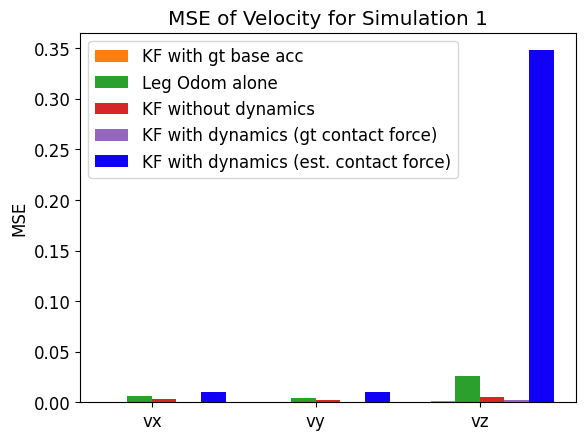

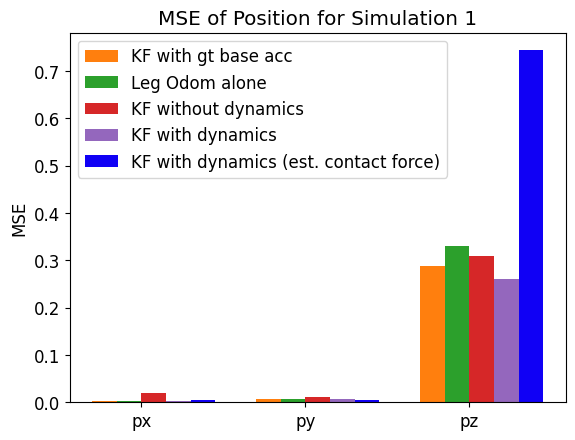

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import os

colors = [#'#1f77b4', # gt
        '#ff7f0e', # gt_acc
        '#2ca02c', # leg odom
        '#d62728', # leg odom + kf, acc=0
        '#9467bd', # leg odom + kf, dynamics
        '#1000f5'  # leg odom + kf, dynamics with est cf
        ]

labels = ["vx", "vy", "vz"]
sim_num = 0
plt.rcParams.update({'font.size': 12})

methodA = mse_result2_gt_acc[:3]
methodB = mse_result_gt_acc[:3]
methodC = mse_result_acc_0[:3]
methodD = mse_result_est_acc_gt_c_force[:3]
methodE = mse_result_est_acc_est_c_force[:3]

x = np.arange(len(labels))
width = 0.15

plt.bar(x - 1.5*width, methodA, width, label="KF with gt base acc", color=colors[0])
plt.bar(x - 0.5*width, methodB, width, label="Leg Odom alone", color=colors[1])
plt.bar(x + 0.5*width, methodC, width, label="KF without dynamics", color=colors[2])
plt.bar(x + 1.5*width, methodD, width, label="KF with dynamics (gt contact force)", color=colors[3])
plt.bar(x + 2.5*width, methodE, width, label="KF with dynamics (est. contact force)", color=colors[4])

plt.xticks(x, labels)
plt.ylabel("MSE")
plt.title("MSE of Velocity for Simulation 1")
plt.legend()

output_folder=f"/home/undefined/Uni/semester-2/RL-IP_Part-1/report/sim{sim_num+1}"
file_name=f"MSE_vel"
os.makedirs(output_folder, exist_ok=True)
plt.savefig(output_folder+"/"+file_name+".pdf", bbox_inches='tight')

plt.show()

labels = ["px", "py", "pz"]

methodA = mse_result2_gt_acc[3:]
methodB = mse_result_gt_acc[3:]
methodC = mse_result_acc_0[3:]
methodD = mse_result_est_acc_gt_c_force[3:]
methodE = mse_result_est_acc_est_c_force[3:]

x = np.arange(len(labels))
width = 0.15

plt.bar(x - 1.5*width, methodA, width, label="KF with gt base acc", color=colors[0])
plt.bar(x - 0.5*width, methodB, width, label="Leg Odom alone", color=colors[1])
plt.bar(x + 0.5*width, methodC, width, label="KF without dynamics", color=colors[2])
plt.bar(x + 1.5*width, methodD, width, label="KF with dynamics", color=colors[3])
plt.bar(x + 2.5*width, methodE, width, label="KF with dynamics (est. contact force)", color=colors[4])

plt.xticks(x, labels)
plt.ylabel("MSE")
plt.title("MSE of Position for Simulation 1")
plt.legend()

output_folder=f"/home/undefined/Uni/semester-2/RL-IP_Part-1/report/sim{sim_num+1}"
file_name=f"MSE_pos"
os.makedirs(output_folder, exist_ok=True)
plt.savefig(output_folder+"/"+file_name+".pdf", bbox_inches='tight')

plt.show()

#### For each method, MSE for vel x,y,z and pos x,y,z averaged over all simulations.

In [32]:
avg_mse_result_gt_acc = [0, 0, 0, 0, 0, 0]
avg_mse_result_leg_odom = [0, 0, 0, 0, 0, 0]
avg_mse_result_no_dynamics = [0, 0, 0, 0, 0, 0]
avg_mse_result_with_dynamics_gt_c_force = [0, 0, 0, 0, 0, 0]
avg_mse_result_with_dynamics_est_c_force = [0, 0, 0, 0, 0, 0]

num_sim = 5
dataset_num = 2

# data_dir = Path.cwd().parent / f"results/simulation/sim_{sim_num+1}"
# result_gt_acc = np.load(f"{data_dir}/leg_odom_alone.npz")

for sim_num in range(num_sim):
    data = load_custom_dataset(dataset_path=Path.cwd().parent / f"custom_datasets/quad_dataset_run{dataset_num}.npz", sim_num=sim_num)

    # Method 1: Estimation with gt base acc
    result_gt_acc = run_state_estimation(dt=data["dt"][0],
                            base_pos=data["base_pos"],
                            base_orient=data["base_orient"],
                            base_acc=data["base_acc"],
                            base_ang_vel=data["base_ang_vel"],
                            joint_pos=data["joint_pos"],
                            joint_vel=data["joint_vel"],
                            contact_states=data["contact_states"],
                            contact_forces=data["contact_forces"],
                            contact_pos=data["contact_pos"],
                            Q=0.0001,
                            R=[1, 1, 1])
    
    for i in range(3):
        avg_mse_result_gt_acc[i] += mean_squared_error(data["base_vel"][:, i], result_gt_acc["vel_update"][:, i])
        avg_mse_result_gt_acc[i+3] += mean_squared_error(data["base_pos"][:, i], result_gt_acc["pos_update"][:, i])
    
    # Method 2: Leg Odom alone
    for i in range(3):
        avg_mse_result_leg_odom[i] += mean_squared_error(data["base_vel"][:, i], result_gt_acc["leg_odom"][:, i])
        avg_mse_result_leg_odom[i+3] += mean_squared_error(data["base_pos"][:, i], result_gt_acc["leg_odom_pos"][:, i])
    
    # Method 3: No dynamics
    result_acc_0 = run_state_estimation(dt=data["dt"][0],
                            base_pos=data["base_pos"],
                            base_orient=data["base_orient"],
                            base_acc=np.zeros(data["base_acc"].shape),
                            base_ang_vel=data["base_ang_vel"],
                            joint_pos=data["joint_pos"],
                            joint_vel=data["joint_vel"],
                            contact_states=data["contact_states"],
                            contact_forces=data["contact_forces"],
                            contact_pos=data["contact_pos"],
                            Q=0.0001,
                            R=[1, 1, 1])
    
    for i in range(3):
        avg_mse_result_no_dynamics[i] += mean_squared_error(data["base_vel"][:, i], result_acc_0["vel_update"][:, i])
        avg_mse_result_no_dynamics[i+3] += mean_squared_error(data["base_pos"][:, i], result_acc_0["pos_update"][:, i])
    
    # Method 4: With dynamics + gt contact_force
    result_est_acc = run_state_estimation(dt=data["dt"][0],
                            base_pos=data["base_pos"],
                            base_orient=data["base_orient"],
                            base_ang_vel=data["base_ang_vel"],
                            joint_pos=data["joint_pos"],
                            joint_vel=data["joint_vel"],
                            contact_states=data["contact_states"],
                            contact_forces=data["contact_forces"],
                            contact_pos=data["contact_pos"],
                            Q=0.0001,
                            R=[1, 1, 1])
    
    for i in range(3):
        avg_mse_result_with_dynamics_gt_c_force[i] += mean_squared_error(data["base_vel"][:, i], result_est_acc["vel_update"][:, i])
        avg_mse_result_with_dynamics_gt_c_force[i+3] += mean_squared_error(data["base_pos"][:, i], result_est_acc["pos_update"][:, i])
    
    # Method 5: With dynamics + est contact_force
    result_est_acc = run_state_estimation(dt=data["dt"][0],
                                      base_pos=data["base_pos"],
                                      base_orient=data["base_orient"],
                                      base_ang_vel=data["base_ang_vel"],
                                      joint_pos=data["joint_pos"],
                                      joint_vel=data["joint_vel"],
                                      joint_torque=data["joint_torque"],
                                      contact_states=data["contact_states"],
                                      contact_pos=data["contact_pos"],
                                      Q=0.0001,
                                      R=[1, 1, 1])
    
    for i in range(3):
        avg_mse_result_with_dynamics_est_c_force[i] += mean_squared_error(data["base_vel"][:, i], result_est_acc["vel_update"][:, i])
        avg_mse_result_with_dynamics_est_c_force[i+3] += mean_squared_error(data["base_pos"][:, i], result_est_acc["pos_update"][:, i])

avg_mse_result_gt_acc = np.array(avg_mse_result_gt_acc) / num_sim
avg_mse_result_leg_odom = np.array(avg_mse_result_leg_odom) / num_sim
avg_mse_result_no_dynamics = np.array(avg_mse_result_no_dynamics) / num_sim
avg_mse_result_with_dynamics_gt_c_force = np.array(avg_mse_result_with_dynamics_gt_c_force) / num_sim
avg_mse_result_with_dynamics_est_c_force = np.array(avg_mse_result_with_dynamics_est_c_force) / num_sim

/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Data loaded from /home/undefined/Uni/semester-2/RL-IP_Part-1/mpx/custom_datasets/quad_dataset_run2.npz.


Estimating state: 100%|██████████| 5000/5000 [00:03<00:00, 1647.40it/s]
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Estimating state: 100%|██████████| 5000/5000 [00:03<00:00, 1664.29it/s]
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Estimating base_acc.


Estimating state: 100%|██████████| 5000/5000 [00:03<00:00, 1608.89it/s]
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


...

Estimating state: 100%|██████████| 5000/5000 [00:02<00:00, 1757.66it/s]
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Estimating state: 100%|██████████| 5000/5000 [00:02<00:00, 1716.84it/s]
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Estimating base_acc.


Estimating state: 100%|██████████| 5000/5000 [00:02<00:00, 1687.15it/s]
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Estimating base_acc.
Estimating contact_force from contact_state and joint_torque


Estimating state: 100%|██████████| 5000/5000 [00:03<00:00, 1313.23it/s]


In [61]:
np.set_printoptions(precision=5, suppress=True)
np.array(mse_result_est_acc_est_c_force)

array([0.01049, 0.01051, 0.348  , 0.0038 , 0.00395, 0.7436 ])

In [68]:
np.set_printoptions(precision=5, suppress=True)
print(avg_mse_result_gt_acc)
print()
print(avg_mse_result_leg_odom)
print()
print(avg_mse_result_no_dynamics)
print()
print(avg_mse_result_with_dynamics_gt_c_force)
print()
print(avg_mse_result_with_dynamics_est_c_force)

[0.00011 0.0001  0.0015  0.00921 0.00509 0.29028]

[0.00646 0.00641 0.02985 0.00943 0.00497 0.32768]

[0.0016  0.00075 0.00442 0.02749 0.00523 0.30721]

[0.00017 0.00019 0.00161 0.00814 0.0047  0.28187]

[0.00495 0.00514 0.20245 0.00794 0.00618 0.69819]


#### Leg Odom + KF with dynamics (estimating base acc with estimated contact force) 

*work in progress*

Estimating base_acc.
Estimating contact_force from contact_state and joint_torque


/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Estimating state: 100%|██████████| 5000/5000 [00:12<00:00, 403.25it/s]


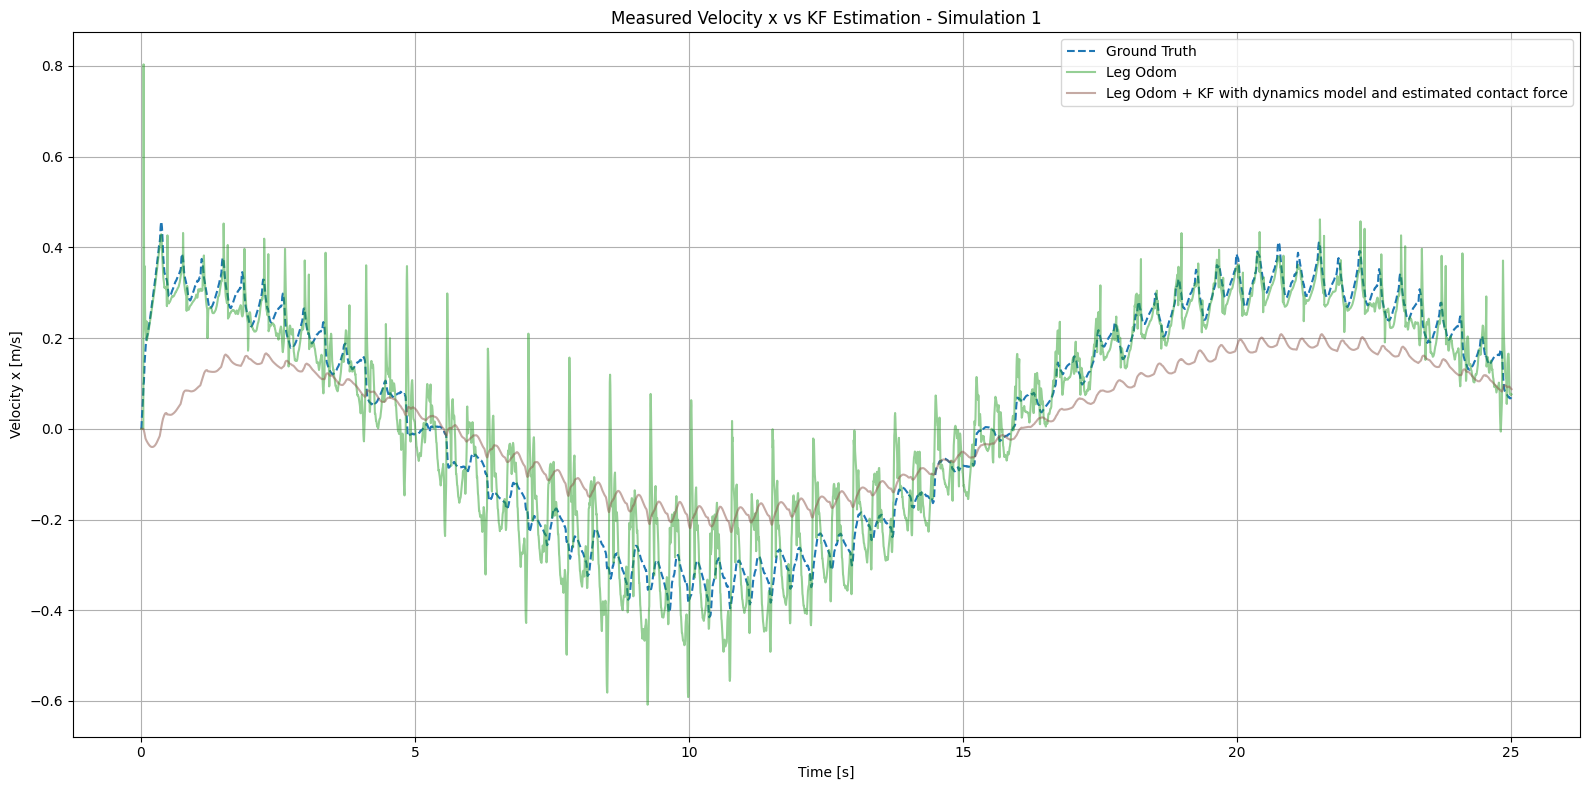

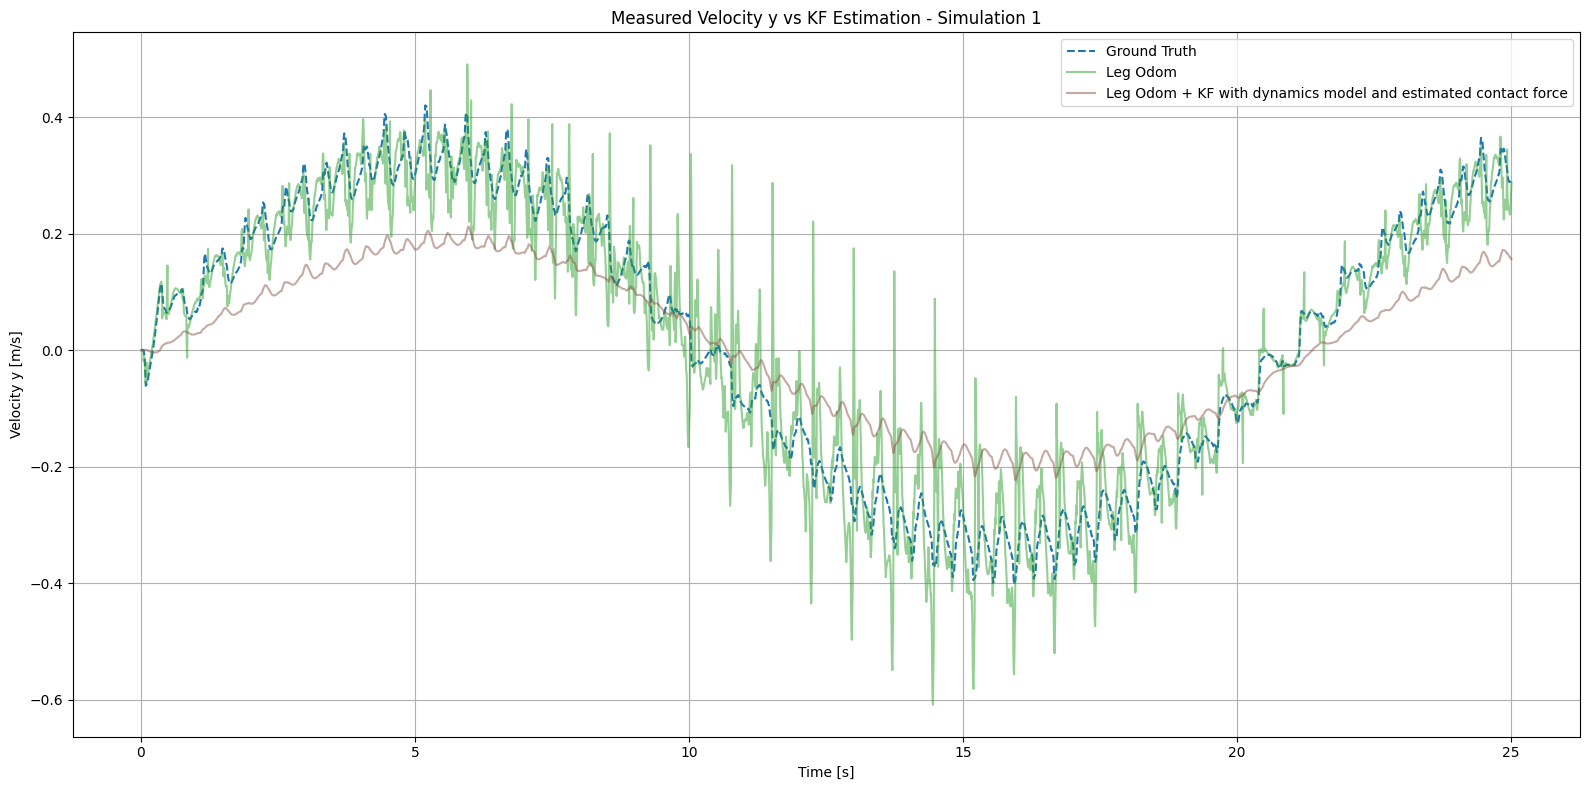

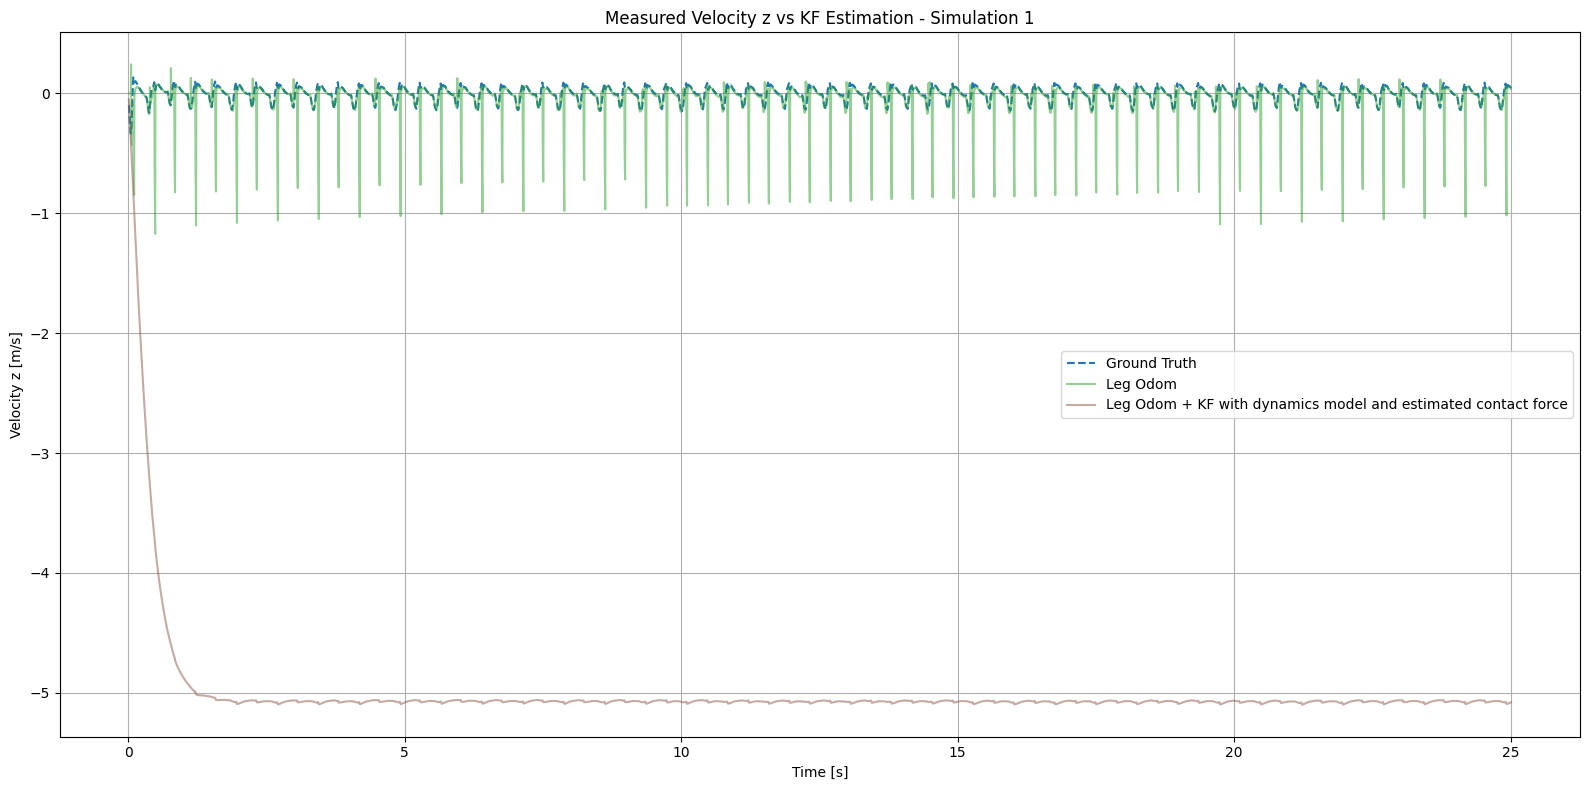

MSE Error of KF Estimation - x: 0.01506036862998009
MSE Error of KF Estimation - y: 0.012292981447783713
MSE Error of KF Estimation - z: 25.235680598141602


In [3]:
colors = ['#1f77b4', # gt
        # '#ff7f0e', # gt_acc
        '#2ca02c', # leg odom
        # '#d62728', # leg odom + kf, acc=0
        # '#9467bd', # leg odom + kf, dynamics
        '#8c564b'  # leg odom + kf, dynamics with est cf
        ]

result_est_acc_and_cf = run_state_estimation(dt=data["dt"][0],
                            base_pos=data["base_pos"],
                            base_orient=data["base_orient"],
                            base_ang_vel=data["base_ang_vel"],
                            joint_pos=data["joint_pos"],
                            joint_vel=data["joint_vel"],
                            joint_torque=data["joint_torque"],
                            contact_states=data["contact_states"],
                            contact_pos=data["contact_pos"],
                            Q=0.0001,
                            R=[1, 1, 1])

mse_result = [0, 0, 0]
dim = ["x", "y", "z"]

for i in range(len(dim)):
    gt_values = data["base_vel"][:, i:i+1]

    pred_values = [result_est_acc_and_cf["leg_odom"][:, i:i+1],
                   result_est_acc_and_cf["vel_update"][:, i:i+1]]

    pred_labels = ["Leg Odom",
                   "Leg Odom + KF with dynamics model and estimated contact force"]

    compare_estimation_plot(time=data["time"],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Velocity {dim[i]} [m/s]",
                            title=f"Measured Velocity {dim[i]} vs KF Estimation - Simulation {sim_num+1}",
                            colors=colors
                            )
    
    mse = mean_squared_error(data["base_vel"][:, i], result_est_acc_and_cf["vel_update"][:, i])
    mse_result[i] += mse

for i in range(len(mse_result)):
    print(f"MSE Error of KF Estimation - {dim[i]}: {mse_result[i]}")

In [7]:
idx = 2000
for i in range(4):
    print(result_est_acc_and_cf["c_force_est"][idx][i], data["contact_forces"][idx][i])

[ 0. -0. -0.] [0. 0. 0.]
[-1.98231767 -2.88804171 -3.96667333] [  6.65221197 -17.05079135 120.32538412]
[ 1.96444433  2.93617755 -3.37092352] [ 4.83963451  7.4784628  93.09412641]
[ 0.  0. -0.] [0. 0. 0.]


In [8]:
import numpy as np

def estimate_contact_forces(joint_torque, contact_state):
    """
    Estimate the forces acting on the contact points (feet) using the dynamics model.
    """

    if contact_state is None or joint_torque is None:
        raise ValueError(f"contact_state and joint_torque are needed to estimate contact_force. contact_state: {contact_state} \t joint_torque: {joint_torque}")
    
    contact_forces = []

    # sum jacobians of all legs that are in contact
    for i in range(4):
        leg_name = env.legs_order[i]

        J_lin = lin_jacobian_w[leg_name][:, 6:]
        c_force = contact_state[i] * (J_lin @ joint_torque)

        contact_forces.append(c_force)
    
    contact_forces = np.array(contact_forces)

    return contact_forces

env = QuadrupedEnv(robot="aliengo")

idx = 2000

env.mjData.qpos[:] = np.concatenate([np.zeros(shape=(3,)), data["base_orient"][idx], data["joint_pos"][idx]])
env.mjData.qvel[:] = np.concatenate([np.zeros(shape=(6,)), data["joint_vel"][idx]])

# calculate lineare jacobian
mujoco.mj_forward(env.mjModel, env.mjData)
lin_jacobian_w = env.feet_jacobians(frame="world")

# c_forces = estimate_contact_forces(data["joint_torque"][idx], data["contact_states"][idx])
# for i in range(4):
#     leg_name = env.legs_order[i]
#     print(leg_name)
#     print(lin_jacobian_w[leg_name][:, 6:])
#     print()

# for i in range(4):
#     print(c_forces[i], data["contact_forces"][idx][i])
lin_jacobian_w

/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


FL=[[ 1.          0.          0.         -0.03141923  0.32242561  0.12041188
  -0.03299161  0.33404449  0.1466176   0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          1.          0.         -0.32773403 -0.04146399 -0.28010172
  -0.32873455 -0.03845233 -0.03009256  0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          1.          0.15762151 -0.27468543  0.00178383
   0.10665557 -0.03501317 -0.20024415  0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]], FR=[[ 1.          0.          0.         -0.04405749  0.34291309 -0.21490776
   0.          0.          0.         -0.04248511  0.36967751  0.22262655
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          1.          0.         -0.35140354 -0.04095172 -0.12267315
   0.          0.          0.         -0.35040302 